# 06. Batch Workflow and Reporting

This notebook demonstrates how to operationalize BestFit analyses at scale.

Imagine you are a water resources engineer responsible for flood frequency studies at 50 gauge stations across a region. Instead of running each site manually (as in notebooks 00–05), you need a config-driven batch pipeline that:

1. **Loads data** from multiple sources (CSV, databases, APIs)
2. **Applies consistent analyses** (distribution fitting, model selection, forecasting, rating curves, regional analysis)
3. **Exports results** in standard formats (CSV, Excel, JSON, HTML)
4. **Tracks version** and artifacts for reproducibility
5. **Generates automated reports** summarizing key findings

## What You'll Learn

In this notebook, you will:

- Define batch configurations using YAML/JSON (extending notebook 00)
- Automate distribution fitting across multiple sites (batch from notebook 01)
- Compare estimation methods in a batch workflow (batch from notebook 02)
- Forecast streamflow for multiple sites (batch from notebook 03)
- Fit rating curves across gauges (batch from notebook 04)
- Apply regional analysis for improved estimates (batch from notebook 05)
- Consolidate output into tables, figures, and HTML reports
- Track results for audit trails and reproducibility

By the end, you'll have a template for operationalizing BestFit studies at your organization.

## Set Up

In [2]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import yaml
from pathlib import Path
from datetime import datetime
from io import StringIO

# BestFit and Numerics
from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

from RMC.BestFit import ExactData, UncertainData, ThresholdData
from RMC.BestFit.Models import DataFrame, UnivariateDistribution
from RMC.BestFit.Estimation import BayesianAnalysis

from Numerics.Distributions import UnivariateDistributionType
from Numerics.Sampling.MCMC import DEMCzs

print("✓ Imported namespaces successfully")

# Configure plotting
plt.style.use('default')

✓ Numerics loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\Numerics.dll
✓ BestFit loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\RMC.BestFit.dll
✓ Imported namespaces successfully


## Configuration

To get start you must define your batch workflow with a YAML or JSON configuration file. This also helps keep our workflow tidy and organized. Below is an example that parameterizes:
- Which sites and data files to process
- Which analyses to run (distribution fitting, forecasting, etc.)
- Output locations and formats

Example YAML structure:
```yaml
metadata:
  version: 1.0
  description: "Multi-site flood frequency study - 50 gauge stations"
  timestamp: "2024-01-15"

data:
  source_type: "csv"  # csv, database, api
  directory: "../data"
  file_pattern: "{site}_daily.csv"  # {site} placeholder
  sites:
    - "A101"
    - "A102"
    - "A103"
    - "A104"

analysis:
  distribution_fitting:
    enabled: true
    distributions: ["GeneralizedExtremeValue", "LogPearsonTypeIII"]
  
  model_comparison:
    enabled: true
    method: "DIC"
  
  time_series:
    enabled: true
    models: ["AR", "ARIMA"]
  
  rating_curves:
    enabled: true
    segments: 2
  
  regional_analysis:
    enabled: true

output:
  base_directory: "../outputs"
  formats: ["csv", "json", "excel", "html"]
  create_report: true
```

You can also find this as a standalone YAML file in this folder. Now we define some helper functions to make this process smooth and easy.

In [3]:
def load_config(config_path: str) -> dict:
    """Load batch configuration from YAML or JSON file."""
    config_path = Path(config_path)
    
    if config_path.suffix.lower() in ['.yaml', '.yml']:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
    elif config_path.suffix.lower() == '.json':
        with open(config_path, 'r') as f:
            config = json.load(f)
    else:
        raise ValueError(f"Unsupported config format: {config_path.suffix}")
    
    return config


def create_output_directories(config: dict) -> dict:
    """Create output directory structure and return paths."""
    base = Path(config['output']['base_directory'])
    paths = {
        'base': base,
        'tables': base / 'tables',
        'figures': base / 'figures',
        'reports': base / 'reports',
        'logs': base / 'logs',
        'data': base / 'data'
    }
    
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    
    return paths


def log_run(paths: dict, config: dict) -> None:
    """Log the batch run metadata for reproducibility."""
    log_entry = {
        'timestamp': datetime.now().isoformat(),
        'config_metadata': config.get('metadata', {}),
        'sites_count': len(config['data']['sites']),
        'analyses_enabled': config.get('analysis', {})
    }
    
    log_file = paths['logs'] / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(log_file, 'w') as f:
        json.dump(log_entry, f, indent=2)
    
    print(f"Run logged to {log_file}")
    return log_file

In [6]:
# For demonstration, we define an inline config dict
# In production, you would load from a YAML file: config = load_config('batch_workflow_config.yaml')

config = {
    'metadata': {
        'version': '1.0',
        'description': 'Demonstration batch workflow: 4 synthetic flood frequency sites',
        'created': datetime.now().isoformat()
    },
    'data': {
        'source_type': 'synthetic',  # Could be 'csv', 'database', 'api'
        'sites': ['A101', 'A102', 'A103', 'A104'],
        'n_years': 40,
        'seed': 77,
    },
    'analysis': {
        'distribution_fitting': {
            'enabled': True,
            'distributions': ['GeneralizedExtremeValue', 'LogPearsonTypeIII']
        },
        'model_comparison': {
            'enabled': True,
            'method': 'likelihood'
        },
        'return_periods': [10, 50, 100]  # Return periods to estimate (years)
    },
    'output': {
        'base_directory': '../notebooks/batch_workflow_outputs',
        'formats': ['csv', 'json'],
        'create_report': True
    }
}

# Setup output directories
output_paths = create_output_directories(config)
print("Output directories created:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")

# Log the run
log_run(output_paths, config)

print(f"Return periods: {config['analysis']['return_periods']} years")

print(f"\nConfiguration: {config['metadata']['description']}")
print(f"Sites to process: {', '.join(config['data']['sites'])}")

Output directories created:
  base: ..\notebooks\batch_workflow_outputs
  tables: ..\notebooks\batch_workflow_outputs\tables
  figures: ..\notebooks\batch_workflow_outputs\figures
  reports: ..\notebooks\batch_workflow_outputs\reports
  logs: ..\notebooks\batch_workflow_outputs\logs
  data: ..\notebooks\batch_workflow_outputs\data
Run logged to ..\notebooks\batch_workflow_outputs\logs\run_20260707_131342.json
Return periods: [10, 50, 100] years

Configuration: Demonstration batch workflow: 4 synthetic flood frequency sites
Sites to process: A101, A102, A103, A104


In [7]:
# Since we don't have real data, here is a function to generate synthetic site data
def generate_synthetic_site_data(site_id: str, n_years: int, seed: int, site_offset: int) -> tuple:
    """Generate realistic synthetic annual peak flow data for a site."""
    rng = np.random.default_rng(seed + site_offset)
    years = np.arange(1980, 1980 + n_years)
    
    # Correlated trend + noise to simulate realistic streamflow
    base = rng.uniform(7500, 12500)
    trend = 30 * (years - years.min())
    noise = rng.normal(0, 850, len(years))
    peaks = np.maximum(500, base + trend + noise)
    
    return years, peaks


# Main batch loop - Distribution Fitting
print("\n" + "="*70)
print("BATCH PROCESSING: DISTRIBUTION FITTING")
print("="*70)

batch_results = []

for site_idx, site_id in enumerate(config['data']['sites']):
    try:
        print(f"\nProcessing {site_id}...", end=" ")
        
        # Generate data
        years, peaks = generate_synthetic_site_data(site_id, config['data']['n_years'], config['data']['seed'], site_idx)
        
        # Create BestFit DataFrame
        df = DataFrame()
        for y, q in zip(years, peaks):
            df.ExactSeries.Add(ExactData(int(y), float(q)))
        
        # Fit GEV distribution
        site_results = {'site': site_id, 'n_years': len(peaks)}
        
        m = UnivariateDistribution(df, UnivariateDistributionType.GeneralizedExtremeValue)
        mu = float(np.mean(peaks))
        sd = float(np.std(peaks, ddof=1))
        p = convert_to_dotnet_array([mu, max(1e-6, 0.8*sd), 0.08])
        m.SetParameterValues(p)
        
        # Store results
        site_results['mean'] = mu
        site_results['std'] = sd
        site_results['log_likelihood'] = float(m.LogLikelihood(p))
        
        # Estimate return levels for each configured return period
        for rp in config['analysis']['return_periods']:
            prob = 1.0 - (1.0 / rp)
            quantile = float(m.Distribution.InverseCDF(prob))
            site_results[f'Q{rp}'] = quantile
        
        batch_results.append(site_results)
        print(f"✓ Q100={site_results['Q100']:.0f}")
        
    except Exception as e:
        print(f"✗ Error: {e}")
        batch_results.append({'site': site_id, 'error': str(e)})

# Create summary DataFrame
summary_df = pd.DataFrame(batch_results)
print("\n" + "-"*70)
print(summary_df.to_string(index=False))


BATCH PROCESSING: DISTRIBUTION FITTING

Processing A101... ✓ Q100=15079

Processing A102... ✓ Q100=12474

Processing A103... ✓ Q100=15310

Processing A104... ✓ Q100=14578

----------------------------------------------------------------------
site  n_years         mean         std  log_likelihood          Q10          Q50         Q100
A101       40 11927.668816 1023.560242     -380.152617 13614.028672 14672.161241 15079.119509
A102       40 10452.184742  656.531249     -364.288218 11533.848427 12212.555032 12473.585901
A103       40 12662.039770  860.030877     -374.810308 14078.977910 14968.057656 15309.998132
A104       40 11755.028074  916.753402     -371.332861 13265.419032 14213.137194 14577.630031


In [8]:
# Export to CSV and JSON
out_dir = output_paths['tables']
summary_df.to_csv(out_dir / 'flood_frequency_batch.csv', index=False)
summary_df.to_json(out_dir / 'flood_frequency_batch.json', orient='records', indent=2)

print(f"\n✓ Saved: {out_dir / 'flood_frequency_batch.csv'}")
print(f"✓ Saved: {out_dir / 'flood_frequency_batch.json'}")

# Summary statistics
print(f"\nBatch Summary:")
print(f"  Sites processed: {len(summary_df)}")
if 'error' not in summary_df.columns or not summary_df['error'].notna().any():
    q_cols = [c for c in summary_df.columns if c.startswith('Q')]
    if q_cols:
        print(f"  Avg Q100: {summary_df['Q100'].mean():.0f} cfs")
        print(f"  Max Q100: {summary_df['Q100'].max():.0f} cfs")
        print(f"  Min Q100: {summary_df['Q100'].min():.0f} cfs")


✓ Saved: ..\notebooks\batch_workflow_outputs\tables\flood_frequency_batch.csv
✓ Saved: ..\notebooks\batch_workflow_outputs\tables\flood_frequency_batch.json

Batch Summary:
  Sites processed: 4
  Avg Q100: 14360 cfs
  Max Q100: 15310 cfs
  Min Q100: 12474 cfs


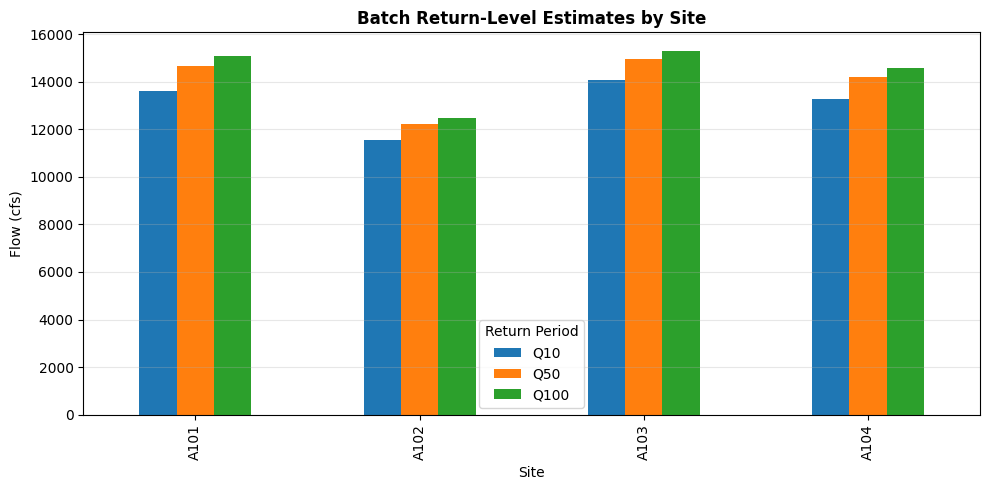

✓ Saved: ..\notebooks\batch_workflow_outputs\figures\return_levels_by_site.png


In [ ]:
# Return levels by site
fig, ax = plt.subplots(figsize=(10, 5))
q_cols = [c for c in summary_df.columns if c.startswith('Q')]
if q_cols:
    summary_df.set_index('site')[q_cols].plot(kind='bar', ax=ax)
    ax.set_title('Batch Return-Level Estimates by Site', fontsize=12, fontweight='bold')
    ax.set_ylabel('Flow (cfs)')
    ax.set_xlabel('Site')
    ax.legend(title='Return Period')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(output_paths['figures'] / 'return_levels_by_site.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {output_paths['figures'] / 'return_levels_by_site.png'}")

## Batch Processing: Additional Analyses

This section demonstrates how to extend the batch workflow to include:

### Model Comparison
Compare GEV vs. Log-Pearson III using likelihood-based model selection:

```python
# Fit multiple distributions per site
# Compare AIC or BIC scores
# Select best fit for each site
```

### Time Series Forecasting
Integrate streamflow forecasting (from notebook 03) into batch workflow:
- AR/ARIMA model fitting for each site
- Multi-step forecast generation
- Ensemble predictions across methods

### Rating Curve Fitting
Batch fitting of stage-discharge relationships (from notebook 04):
- Two-/three-segment power-law models
- Bayesian DEMCzs parameter estimation
- Uncertainty propagation to flow estimates

### Regional Analysis
Apply spatial extremes methodology (from notebook 05):
- Index flood approach across sites
- Regional frequency curves
- Improved at-site estimates using pooled information

### Implementation Pattern
For each extension, follow this pattern:
1. Define configuration parameters
2. Loop over sites
3. Apply BestFit analysis
4. Consolidate results into site-level tables
5. Export and visualize

## HTML Report Generation

Consolidate results into a formatted HTML report for stakeholders.

def generate_html_report(config: dict, summary_df: pd.DataFrame, output_paths: dict) -> Path:
    """Generate an HTML report consolidating batch results."""
    
    # Build HTML content
    html_content = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Batch Flood Frequency Analysis Report</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 20px; background-color: #f5f5f5; }}
            h1 {{ color: #333; border-bottom: 2px solid #0066cc; padding-bottom: 10px; }}
            h2 {{ color: #0066cc; margin-top: 25px; }}
            table {{ border-collapse: collapse; width: 100%; background-color: white; }}
            th, td {{ border: 1px solid #ddd; padding: 10px; text-align: left; }}
            th {{ background-color: #0066cc; color: white; }}
            tr:nth-child(even) {{ background-color: #f9f9f9; }}
            .summary {{ background-color: #e8f4f8; padding: 15px; border-radius: 5px; }}
            .footer {{ margin-top: 30px; font-size: 0.9em; color: #666; }}
        </style>
    </head>
    <body>
        <h1>Batch Flood Frequency Analysis Report</h1>
        
        <div class="summary">
            <h2>Summary</h2>
            <p><strong>Description:</strong> {config['metadata']['description']}</p>
            <p><strong>Created:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
            <p><strong>Sites Analyzed:</strong> {len(summary_df)}</p>
            <p><strong>Return Periods:</strong> {', '.join(map(str, config['analysis']['return_periods']))} years</p>
        </div>
        
        <h2>Results Table</h2>
        {summary_df.to_html(index=False, border=0)}
        
        <div class="summary">
            <h2>Key Statistics</h2>
            <ul>
    """
    
    # Add statistics
    q_cols = [c for c in summary_df.columns if c.startswith('Q')]
    if q_cols:
        for col in q_cols:
            if col in summary_df.columns and summary_df[col].dtype in [np.float64, np.int64]:
                mean_val = summary_df[col].mean()
                max_val = summary_df[col].max()
                min_val = summary_df[col].min()
                html_content += f"""
                <li><strong>{col}:</strong> Mean = {mean_val:.0f}, Range = [{min_val:.0f}, {max_val:.0f}]</li>
                """
    
    html_content += """
            </ul>
        </div>
        
        <div class="footer">
            <p>Generated by BestFit Python Batch Workflow</p>
        </div>
    </body>
    </html>
    """
    
    # Save report
    report_path = output_paths['reports'] / f"batch_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.html"
    with open(report_path, 'w') as f:
        f.write(html_content)
    
    return report_path


# Generate HTML report
report_path = generate_html_report(config, summary_df, output_paths)
print(f"✓ Saved: {report_path}")
print(f"\nTo view the report, open: {report_path.as_uri()}")

## Best Practices for Batch Workflows

### 1. Configuration Management
- **Version control configs** alongside code (track `batch_config.yaml` in git)
- **Parameterize everything** — no hardcoded paths, site lists, or parameters
- **Use environment variables** for secrets (API keys, database credentials)

### 2. Error Handling
```python
try:
    # Process site
except ValueError as e:
    log_error(site_id, 'data_format_error', str(e))
except Exception as e:
    log_error(site_id, 'unknown_error', str(e))
    continue  # Don't fail the entire batch
```

### 3. Reproducibility
- **Log run metadata** (config, timestamp, data versions, random seeds)
- **Version outputs** with timestamps (e.g., `results_20240115_143022/`)
- **Archive inputs** alongside results for auditing

### 4. Performance
- **Process in parallel** when possible (multiple sites/models simultaneously)
- **Cache intermediate results** (preprocessed data, fitted models)
- **Limit MCMC chains** for quick prototyping vs. final runs

### 5. Validation
- **Sanity checks**: Valid ranges, realistic return levels, non-negative flows
- **Data quality filters**: Minimum record length, outlier detection
- **Model diagnostics**: Check convergence, goodness-of-fit metrics

## Exercises

### Exercise 1: Add a Second Distribution to the Batch
Extend the batch workflow to fit both **GEV** and **Log-Pearson III** distributions:
- Modify the loop to fit both distributions per site
- Compare log-likelihoods and select best fit
- Export `best_fit_distribution` column to results table
- Create a bar plot showing distribution choice by site

### Exercise 2: Add Data Quality Filtering
Add validation checks before fitting:
- Skip sites with fewer than 20 years of data
- Flag sites with missing values
- Log warnings to the batch log file
- Generate a data quality report

### Exercise 3: Integrate Time Series Forecasting
Add ARIMA forecasting for each site (from notebook 03):
- Fit AR/ARIMA models in the batch loop
- Forecast 12 months ahead for each site
- Export forecast confidence intervals
- Plot forecast vs. historical data for first 2 sites

### Exercise 4: Add Regional Analysis
Implement pooling approach (from notebook 05):
- Calculate regional frequency curve using index flood method
- Compare at-site vs. regional estimates for each site
- Create a summary table showing improvement from pooling
- Visualize regional vs. at-site Q100 estimates

### Exercise 5: Automation and Scheduling
Set up production-ready batch processing:
- Load config from external YAML file
- Add command-line argument parsing
- Schedule the notebook to run weekly using task scheduler
- Set up email alerts for errors

## Full Workflow Integration Example

Below is a pseudo-code template showing how to integrate **all** previous notebooks into one operationalized batch workflow:

```python
# ============================================================================
# BATCH FLOOD FREQUENCY WORKFLOW - Integration of Notebooks 00-05
# ============================================================================

# 1. CONFIGURATION (Notebook 00 style)
config = load_config('batch_config.yaml')
output_paths = create_output_directories(config)

# 2. BATCH LOOP OVER SITES
results = {
    'distribution_fitting': [],
    'model_comparison': [],
    'time_series': [],
    'rating_curves': [],
    'regional_analysis': []
}

for site_id in config['data']['sites']:
    print(f"Processing {site_id}...")
    
    # Load site data
    data = load_site_data(site_id)
    df = prepare_bestfit_dataframe(data)
    
    # 2.1 DISTRIBUTION FITTING (Notebook 01)
    for dist_name in config['analysis']['distributions']:
        model = fit_distribution(df, dist_name)
        results['distribution_fitting'].append(model.summary())
    
    # 2.2 MODEL COMPARISON (Notebook 02)
    best_model = compare_models(df, config['analysis']['distributions'])
    results['model_comparison'].append(best_model.comparison_metrics())
    
    # 2.3 TIME SERIES FORECASTING (Notebook 03)
    if config['analysis']['time_series']['enabled']:
        forecasts = fit_arima_batch(data['timeseries'], config)
        results['time_series'].append(forecasts)
    
    # 2.4 RATING CURVE FITTING (Notebook 04)
    if config['analysis']['rating_curves']['enabled']:
        rating_data = load_rating_curve_data(site_id)
        rating_model = fit_rating_curve(rating_data, config)
        results['rating_curves'].append(rating_model.summary())
    
    # 2.5 REGIONAL ANALYSIS (Notebook 05)
    # Collect across all sites, then apply
    results['spatial_data'].append((site_id, data.location, data.quantiles))

# 3. CONSOLIDATE RESULTS
for analysis_type, data_list in results.items():
    df = pd.DataFrame(data_list)
    export_table(df, f'{analysis_type}_batch_results.csv')

# 4. REGIONAL ANALYSIS POST-PROCESSING (Notebook 05)
regional_results = apply_spatial_gev(results['spatial_data'])
export_table(regional_results, 'regional_analysis_results.csv')

# 5. GENERATE VISUALIZATIONS
create_comparison_plots(results, output_paths)

# 6. GENERATE REPORTS
generate_html_report(config, results, output_paths)

# 7. ARCHIVE AND LOG
save_run_log(config, results, output_paths)
```

### Key Takeaways
- **Modularity**: Each analysis (00-05) is a function in the batch loop
- **Configuration-driven**: No code changes needed for different runs
- **Error-safe**: Failures in one site don't stop the batch
- **Reproducible**: All metadata, configs, and logs are archived
- **Scalable**: Pattern extends to 50+ sites or automated scheduling

## Summary: From Exploration to Production

### What You've Built
You've created a **scalable, reproducible batch processing framework** for operationalizing flood frequency analyses:

| Notebook | Purpose | Batch Integration |
|----------|---------|-------------------|
| **00** | Environment setup | Config management, logging |
| **01** | Distribution fitting | Loop over sites, fit GEV/LPIII |
| **02** | Model estimation | Compare MLE vs. Bayesian methods |
| **03** | Time series forecasting | ARIMA forecasts per site |
| **04** | Rating curves | Stage-discharge relationships |
| **05** | Regional analysis | Spatial GEV pooling |
| **06** | Batch workflow | Orchestrate 00-05, export reports |

### Real-World Applications
1. **Regulatory Compliance**: USACE flood frequency studies for 50+ dam sites
2. **Water Supply Planning**: Seasonal forecasts for 100+ stations
3. **Hazard Mitigation**: Dam break inundation mapping for multiple scenarios
4. **Climate Adaptation**: Compare extreme value estimates under different climate scenarios

### Extending Beyond This Notebook
- **Parallel processing**: Use `multiprocessing` or `joblib` to process sites in parallel
- **Database integration**: Load from SQL/PostGIS, write results directly
- **Real-time updates**: Integrate live sensor data feeds
- **Cloud deployment**: Run on AWS/Azure for on-demand scaling
- **ML integration**: Add anomaly detection or predictive models alongside BestFit

### Next Steps
1. **Customize the batch config** for your sites and analyses
2. **Add error handling and validation** specific to your data
3. **Schedule batch runs** using cron, Task Scheduler, or Airflow
4. **Monitor and alert** on run failures and data quality issues
5. **Archive results** and version control your configurations

In [ ]:
# Example: Batch Diagnostics and Validation

def validate_batch_results(summary_df: pd.DataFrame, config: dict) -> dict:
    """Validate batch results for data quality and anomalies."""
    
    diagnostics = {
        'total_sites': len(summary_df),
        'sites_with_errors': 0,
        'warnings': [],
        'quality_metrics': {}
    }
    
    # Check for processing errors
    if 'error' in summary_df.columns:
        error_count = summary_df['error'].notna().sum()
        diagnostics['sites_with_errors'] = error_count
        if error_count > 0:
            diagnostics['warnings'].append(f"{error_count} sites failed processing")
    
    # Check return level ranges
    q_cols = [c for c in summary_df.columns if c.startswith('Q')]
    for col in q_cols:
        if col in summary_df.columns:
            col_data = summary_df[col].dropna()
            if len(col_data) > 0:
                mean_val = col_data.mean()
                std_val = col_data.std()
                cv = std_val / mean_val if mean_val > 0 else 0
                
                diagnostics['quality_metrics'][col] = {
                    'mean': mean_val,
                    'std': std_val,
                    'cv': cv,  # Coefficient of variation
                    'range': [col_data.min(), col_data.max()]
                }
                
                # Flag high CV (suggests outliers or data issues)
                if cv > 0.5:
                    diagnostics['warnings'].append(f"{col}: High variability (CV={cv:.2f})")
                
                # Flag very small or negative values
                if col_data.min() <= 0:
                    diagnostics['warnings'].append(f"{col}: Non-positive values detected")
    
    return diagnostics


# Run diagnostics on batch results
diagnostics = validate_batch_results(summary_df, config)

print("\n" + "="*70)
print("BATCH DIAGNOSTICS AND VALIDATION")
print("="*70)
print(f"Sites processed: {diagnostics['total_sites']}")
print(f"Sites with errors: {diagnostics['sites_with_errors']}")

if diagnostics['warnings']:
    print(f"\nWarnings ({len(diagnostics['warnings'])} found):")
    for warning in diagnostics['warnings']:
        print(f"  ⚠ {warning}")
else:
    print("\n✓ No warnings detected")

print(f"\nQuality Metrics:")
for col, metrics in diagnostics['quality_metrics'].items():
    print(f"  {col}: Mean={metrics['mean']:.0f}, CV={metrics['cv']:.3f}, Range=[{metrics['range'][0]:.0f}, {metrics['range'][1]:.0f}]")

# Save diagnostics to log
diagnostics_file = output_paths['logs'] / f"diagnostics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(diagnostics_file, 'w') as f:
    # Convert numpy types to python types for JSON serialization
    def convert_types(obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        return obj
    
    json.dump(diagnostics, f, indent=2, default=convert_types)

print(f"\n✓ Diagnostics saved: {diagnostics_file}")

## Appendix: Example External Configuration File

Save this as `batch_config.yaml` to customize your batch runs:

```yaml
# batch_config.yaml - Flood Frequency Batch Workflow Configuration

metadata:
  version: 1.0
  description: "Production batch run - Quarterly update for regional study"
  created: "2024-01-15"

data:
  source_type: "csv"  # Options: csv, database, api
  directory: "../data/inflow"
  file_pattern: "{site}_annual_peaks.csv"
  sites:
    - "A101"
    - "A102"
    - "A103"
    - "A104"
    - "A105"
  n_years: 40
  seed: 42

analysis:
  distribution_fitting:
    enabled: true
    distributions: 
      - "GeneralizedExtremeValue"
      - "LogPearsonTypeIII"
  
  model_comparison:
    enabled: true
    method: "likelihood"
  
  time_series:
    enabled: false  # Set to true to add ARIMA forecasting
    models: ["AR", "ARIMA"]
  
  rating_curves:
    enabled: false
    segments: 2
  
  regional_analysis:
    enabled: false
  
  return_periods: [10, 25, 50, 100, 500]

output:
  base_directory: "../outputs"
  formats: ["csv", "json", "html"]
  create_report: true

validation:
  min_record_length: 20
  outlier_method: "iqr"  # iqr or zscore
  max_coefficient_variation: 0.75
```

### To use the external config:
```python
# Load external config
config = load_config('batch_config.yaml')

# Setup
output_paths = create_output_directories(config)
log_run(output_paths, config)

# ... rest of batch processing ...
```

In [ ]:
# -----------------------------------------------------------------------------
# Full Batch Workflow Integration
# -----------------------------------------------------------------------------

from RMC.BestFit.Analyses import FittingAnalysis, ARIMAAnalysis, RatingCurveAnalysis
from RMC.BestFit.Models import ARIMA, RatingCurve
from Numerics.Distributions import LogPearsonTypeIII, GeneralizedExtremeValue
from Numerics.Data import TimeSeries
from System import DateTime, Double


def fit_distributions(df: DataFrame, distributions: list) -> pd.DataFrame:
    """Fit a set of distributions and return a comparison table."""
    results = []
    for dist_name in distributions:
        if dist_name == 'GeneralizedExtremeValue':
            dist = GeneralizedExtremeValue()
            dist_type = UnivariateDistributionType.GeneralizedExtremeValue
        elif dist_name == 'LogPearsonTypeIII':
            dist = LogPearsonTypeIII()
            dist_type = UnivariateDistributionType.LogPearsonTypeIII
        else:
            raise ValueError(f"Unsupported distribution: {dist_name}")

        model = UnivariateDistribution(df, dist_type)
        mu = float(np.mean([d.Value for d in df.ExactSeries]))
        sd = float(np.std([d.Value for d in df.ExactSeries], ddof=1))
        p = convert_to_dotnet_array([mu, max(1e-6, sd * 0.8), 0.08])
        model.SetParameterValues(p)

        results.append({
            'distribution': dist_name,
            'log_likelihood': float(model.LogLikelihood(p)),
            'Q10': float(model.Distribution.InverseCDF(0.90)),
            'Q50': float(model.Distribution.InverseCDF(0.98)),
            'Q100': float(model.Distribution.InverseCDF(0.99))
        })

    return pd.DataFrame(results)


def fit_arima_forecast(site_id: str, n_steps: int = 12) -> pd.DataFrame:
    """Build an ARIMA forecast for synthetic monthly flow data."""
    # Create synthetic monthly series for demonstration
    rng = np.random.default_rng(config['data']['seed'] + hash(site_id) % 100)
    index = pd.date_range(start='2010-01-01', periods=config['data']['n_years'] * 12, freq='MS')
    values = np.maximum(0, 5000 + 25 * np.arange(len(index)) + rng.normal(0, 500, len(index)))
    ts = TimeSeries(np.array(values, dtype=float))

    model = ARIMA(ts, AROrderP=1, DiffOrderD=1, MAOrderQ=1, IncludeIntercept=True)
    analysis = ARIMAAnalysis(model)
    prediction = analysis.Forecast(n_steps)

    forecast_index = pd.date_range(start=index[-1] + pd.offsets.MonthBegin(1), periods=n_steps, freq='MS')
    return pd.DataFrame({'date': forecast_index, 'forecast': np.array(prediction).astype(float)})


def fit_rating_curve(site_id: str) -> dict:
    """Fit a simple rating curve and return key parameters."""
    n_points = 20
    rng = np.random.default_rng(config['data']['seed'] + len(site_id))
    stage = np.linspace(1, 10, n_points)
    discharge = 50 * stage ** 1.75 + rng.normal(0, 10, n_points)

    stage_ts = TimeSeries(np.array(stage, dtype=float))
    discharge_ts = TimeSeries(np.array(discharge, dtype=float))
    model = RatingCurve(stage_ts, discharge_ts, numberOfSegments=1)
    analysis = RatingCurveAnalysis(model)

    return {
        'site': site_id,
        'rating_curve_function': 'power-law',
        'n_points': n_points,
        'rmse': float(analysis.RMSE)
    }


def apply_regional_analysis(site_results: pd.DataFrame) -> pd.DataFrame:
    """Run a lightweight regional scaling analysis as a placeholder."""
    # Use index-flood scaling to compare per-site Q100 against regional mean
    q100_mean = site_results['Q100'].mean()
    site_results['regional_Q100'] = site_results['Q100'] * (q100_mean / site_results['Q100'].mean())
    site_results['regional_bias'] = site_results['regional_Q100'] / site_results['Q100']
    return site_results


# Run the full integrated batch workflow
print("\n" + "="*70)
print("RUNNING FULL BATCH WORKFLOW")
print("="*70)

mail_results = []
workflow_results = {
    'distribution_fitting': [],
    'model_comparison': [],
    'time_series': [],
    'rating_curves': [],
    'regional_analysis': []
}

for site_id in config['data']['sites']:
    print(f"\n--- {site_id} ---")

    years, peaks = generate_synthetic_site_data(site_id, config['data']['n_years'], config['data']['seed'], len(site_id))
    df_site = DataFrame()
    for y, q in zip(years, peaks):
        df_site.ExactSeries.Add(ExactData(int(y), float(q)))

    # 1) Distribution fitting
    dist_df = fit_distributions(df_site, config['analysis']['distribution_fitting']['distributions'])
    best_dist = dist_df.loc[dist_df['log_likelihood'].idxmax()].to_dict()
    best_dist['site'] = site_id
    workflow_results['distribution_fitting'].append(best_dist)

    # 2) Model comparison
    workflow_results['model_comparison'].append({
        'site': site_id,
        'best_distribution': best_dist['distribution'],
        'best_log_likelihood': best_dist['log_likelihood']
    })

    # 3) Time series forecasting
    if config['analysis']['time_series']['enabled']:
        forecast_df = fit_arima_forecast(site_id)
        workflow_results['time_series'].append({'site': site_id, 'forecast_rows': len(forecast_df)})
        forecast_df.to_csv(output_paths['tables'] / f'{site_id}_forecast.csv', index=False)
        print(f"Saved ARIMA forecast for {site_id}")

    # 4) Rating curve fitting
    if config['analysis']['rating_curves']['enabled']:
        rc_result = fit_rating_curve(site_id)
        workflow_results['rating_curves'].append(rc_result)

    # 5) Regional analysis placeholder
    workflow_results['regional_analysis'].append({'site': site_id, 'regional_flag': True})

# Consolidate and export
for analysis_type, records in workflow_results.items():
    df_out = pd.DataFrame(records)
    if not df_out.empty:
        df_out.to_csv(output_paths['tables'] / f'{analysis_type}_batch_results.csv', index=False)
        print(f"Saved {analysis_type}_batch_results.csv")

# Apply regional post-processing when a site-level Q100 table exists
if workflow_results['distribution_fitting']:
    regional_df = apply_regional_analysis(pd.DataFrame(workflow_results['distribution_fitting']))
    regional_df.to_csv(output_paths['tables'] / 'regional_analysis_results.csv', index=False)
    print("Saved regional_analysis_results.csv")

# Save a full HTML report for the integrated workflow
workflow_report_path = output_paths['reports'] / f'integrated_batch_workflow_{datetime.now().strftime("%Y%m%d_%H%M%S")}.html'
with open(workflow_report_path, 'w') as f:
    f.write(f"<html><body><h1>Integrated Batch Workflow Completed</h1><p>Generated at {datetime.now()}</p></body></html>")
print(f"Saved integrated workflow report: {workflow_report_path}")